# Análisis de Segmentación de Clientes y Comportamiento de Compra

Reproduce la metodología del análisis anterior (README_pasado.pdf, dic-2025).

## Origen de los datos: `df_vip.csv`

Este archivo contiene las **transacciones del programa de fidelización VIP** de Euro Supermercados.
Cada fila es un ítem vendido en un ticket, y el `user_id` corresponde a la **cédula de ciudadanía**
del cliente registrado en el sistema POS al momento de la compra.

| Columna | Descripción |
|---------|-------------|
| `tiket_id` | Identificador único del ticket (ej: `Y13-81936`) |
| `date_sale` | Fecha de la venta |
| `user_id` | Cédula del cliente (programa VIP) |
| `tiket_price` | Valor **total** del ticket (mismo para todos los ítems del ticket) |
| `amount` | Cantidad del producto comprado |
| `category` | Categoría del producto (191 categorías) |
| `product_name` | Nombre del producto |
| `id_point_sale` | Punto de venta (ej: FRO, SAL, SAB — ~20 tiendas) |

**Nota importante:** `tiket_price` es el valor total del ticket, NO del ítem individual.
Por eso se trabaja con `drop_duplicates()` sobre `tiket_id` para obtener tickets únicos.

## Metodología

1. **Limpieza de IDs** — Validación de cédula colombiana (6-10 dígitos, sin genéricos)
2. **K-Means con k=4** — 6 features de comportamiento de compra
3. **Evolución mensual** — Frecuencia y valor del ticket por mes
4. **Canasta "de combate"** — Top productos por penetración
5. **Ciclo de supervivencia** — Gasto por día del mes (nómina/quincena)
6. **Clientes en caída** — P1 (Ene-Jul) vs P2 (Ago-Dic)
7. **"Efecto recorte"** — Cambio en consumo por producto

## 1. Setup

In [20]:
import os
from pathlib import Path

# Ir al directorio raíz del proyecto (donde está params.yaml)
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path("..").resolve()
# Buscar el directorio que contiene params.yaml
if not (PROJECT_ROOT / "params.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT / "euro"
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

SEED = 42
N_CLUSTERS = 4
FEATURE_COLS = [
    "ticket_promedio",
    "valor_tipico",
    "gasto_total_vida",
    "volatilidad_gasto",
    "frecuencia_total",
    "dias_sin_comprar",
]

# Colores por cluster (como en el PDF)
CLUSTER_COLORS_LIST = ["#9b59b6", "#7986cb", "#f0c27a", "#d4e157"]

print(f"Directorio: {os.getcwd()}")
print(f"params.yaml existe: {(Path('params.yaml')).exists()}")

Directorio: /Users/juandavidrincon/Documents/euro_nuevo_nov/euro
params.yaml existe: True


## 2. Carga y Limpieza de Datos

### Limpieza de `user_id` (cédula colombiana)

Se aplican los mismos filtros que usa el pipeline de producción (`src/client_filters.py`):

| Regla | Qué filtra | Ejemplo |
|-------|-----------|--------|
| Solo dígitos | IDs con letras o caracteres especiales | `ABC123` |
| No empieza en "0" | Cédulas inválidas | `0000`, `069104477` |
| Longitud 6-10 | IDs muy cortos o muy largos | `30332`, `000000000000` |
| No genéricos | IDs de prueba o repetitivos | `111111`, `9999999`, `1234567890` |
| No repetitivos | Un solo dígito repetido | `22222222222222222222` |

In [21]:
# --- Carga ---
# Intentar parquet primero (formato nuevo), fallback a CSV (formato legacy)
vip_path_parquet = Path("data/processed/df_vip.parquet")
vip_path_csv = Path("data/processed/df_vip.csv")

if vip_path_parquet.exists():
    df_master = pd.read_parquet(vip_path_parquet)
    print(f"Cargado desde parquet: {vip_path_parquet}")
elif vip_path_csv.exists():
    df_master = pd.read_csv(vip_path_csv, low_memory=False)
    print(f"Cargado desde CSV (legacy): {vip_path_csv}")
else:
    raise FileNotFoundError(
        "No se encontró df_vip.parquet ni df_vip.csv en data/processed/.\n"
        "Ejecuta: uv run python src/download_vip.py --download --process"
    )

df_master["date_sale"] = pd.to_datetime(df_master["date_sale"])
df_master["user_id"] = df_master["user_id"].astype(str).str.strip()

# Filtrar tickets negativos
df_master = df_master[df_master["tiket_price"] > 0].copy()

print(f"\nFilas totales: {len(df_master):,}")
print(f"Clientes únicos: {df_master['user_id'].nunique():,}")
print(f"Tickets únicos: {df_master['tiket_id'].nunique():,}")
print(f"Rango: {df_master['date_sale'].min().date()} → {df_master['date_sale'].max().date()}")

Cargado desde CSV (legacy): data/processed/df_vip.csv

Filas totales: 24,298,037
Clientes únicos: 73,560
Tickets únicos: 2,574,062
Rango: 2025-01-01 → 2025-12-07


In [22]:
# --- Limpieza de user_id (cédula colombiana CC) ---

BLACKLIST_IDS = {
    "0", "1", "12345", "123456", "1234567", "12345678",
    "123456789", "1234567890",
    "111111", "1111111", "11111111", "111111111", "1111111111",
    "222222", "2222222", "22222222", "222222222", "2222222222",
    "333333", "3333333", "33333333", "333333333", "3333333333",
    "444444", "4444444", "44444444", "444444444", "4444444444",
    "555555", "5555555", "55555555", "555555555", "5555555555",
    "666666", "6666666", "66666666", "666666666", "6666666666",
    "777777", "7777777", "77777777", "777777777", "7777777777",
    "888888", "8888888", "88888888", "888888888", "8888888888",
    "999999", "9999999", "99999999", "999999999", "9999999999",
}

MIN_CC, MAX_CC = 6, 10

ids = df_master["user_id"]
mask_digitos = ids.str.fullmatch(r"\d+", na=False)
mask_no_cero = ~ids.str.startswith("0", na=False)
mask_longitud = ids.str.len().between(MIN_CC, MAX_CC)
mask_no_blacklist = ~ids.isin(BLACKLIST_IDS)
mask_no_repetitivo = ids.apply(lambda s: len(set(s)) > 1)

mask_valido = mask_digitos & mask_no_cero & mask_longitud & mask_no_blacklist & mask_no_repetitivo

n_total = len(df_master)
n_invalidos = (~mask_valido).sum()
clientes_antes = df_master["user_id"].nunique()
clientes_invalidos = df_master.loc[~mask_valido, "user_id"].nunique()

print("--- Reporte de limpieza de user_id ---")
print(f"  No son dígitos:     {(~mask_digitos).sum():>10,} filas")
print(f"  Empiezan en 0:      {(mask_digitos & ~mask_no_cero).sum():>10,} filas")
print(f"  Longitud inválida:  {(mask_digitos & mask_no_cero & ~mask_longitud).sum():>10,} filas")
print(f"  IDs genéricos:      {(mask_digitos & mask_no_cero & mask_longitud & ~mask_no_blacklist).sum():>10,} filas")
print(f"  IDs repetitivos:    {(mask_digitos & mask_no_cero & mask_longitud & mask_no_blacklist & ~mask_no_repetitivo).sum():>10,} filas")
print(f"  ---")
print(f"  Total eliminadas:   {n_invalidos:>10,} filas ({n_invalidos/n_total*100:.2f}%)")
print(f"  Clientes eliminados: {clientes_invalidos:>9,} de {clientes_antes:,}")

# Aplicar filtro
df_master = df_master[mask_valido].copy()
print(f"\nDatos limpios: {len(df_master):,} filas, {df_master['user_id'].nunique():,} clientes")

--- Reporte de limpieza de user_id ---
  No son dígitos:             26 filas
  Empiezan en 0:           2,757 filas
  Longitud inválida:       9,274 filas
  IDs genéricos:             129 filas
  IDs repetitivos:             0 filas
  ---
  Total eliminadas:       12,186 filas (0.05%)
  Clientes eliminados:        44 de 73,560

Datos limpios: 24,285,851 filas, 73,516 clientes


## 3. Feature Engineering (6 variables)

Se calculan **por cliente** a partir de sus tickets únicos:

| Feature | Cálculo | Qué separa |
|---------|---------|------------|
| `ticket_promedio` | `mean(tiket_price)` | Ballenas (alto) vs Reposición (bajo) |
| `valor_tipico` | `median(tiket_price)` | Valor "normal" sin outliers |
| `gasto_total_vida` | `sum(tiket_price)` | Valor de vida del cliente |
| `volatilidad_gasto` | `std(tiket_price)` | Estabilidad del comportamiento |
| `frecuencia_total` | `count(tickets)` | Clientes frecuentes vs esporádicos |
| `dias_sin_comprar` | `max_date - last_purchase` | Riesgo de abandono |

In [23]:
# Extraer tickets únicos
# tiket_price es el valor TOTAL del ticket (mismo para todos los ítems),
# por eso usamos drop_duplicates para no contar el mismo ticket N veces.
df_tickets = df_master[["tiket_id", "user_id", "tiket_price", "date_sale"]].drop_duplicates()

print(f"Tickets únicos: {len(df_tickets):,}")
print(f"Ticket promedio global: ${df_tickets['tiket_price'].mean():,.0f}")
print(f"Ticket mediana global:  ${df_tickets['tiket_price'].median():,.0f}")

# Features por usuario (idéntico a la metodología de eda.ipynb)
ref_date = df_tickets["date_sale"].max()

user_features = df_tickets.groupby("user_id").agg({
    "tiket_price": ["mean", "median", "sum", "std"],
    "tiket_id": "count",
    "date_sale": lambda x: (ref_date - x.max()).days,
}).fillna(0)

user_features.columns = FEATURE_COLS

print(f"\nFeatures calculadas para {len(user_features):,} clientes")
print(f"Fecha de referencia: {ref_date.date()}")
print()
user_features.describe().round(1)

Tickets únicos: 2,572,214
Ticket promedio global: $107,907
Ticket mediana global:  $45,654

Features calculadas para 73,516 clientes
Fecha de referencia: 2025-12-07



,ticket_promedio,valor_tipico,gasto_total_vida,volatilidad_gasto,frecuencia_total,dias_sin_comprar
count,73516.0,73516.0,73516.0,73516.0,73516.0,73516.0
mean,131249.3,107909.7,3775508.6,105316.3,35.0,22.0
std,135879.7,136257.4,5488405.5,104864.4,43.2,31.6
min,1532.0,1108.0,16852.0,0.0,7.0,0.0
25%,47371.6,33268.8,1099864.0,38141.7,15.0,4.0
50%,90144.8,64065.2,2354692.5,75117.9,23.0,9.0
75%,167617.2,128655.8,4816636.5,138215.9,38.0,27.0
max,5623774.2,4810404.0,714170201.0,4674024.6,1861.0,279.0


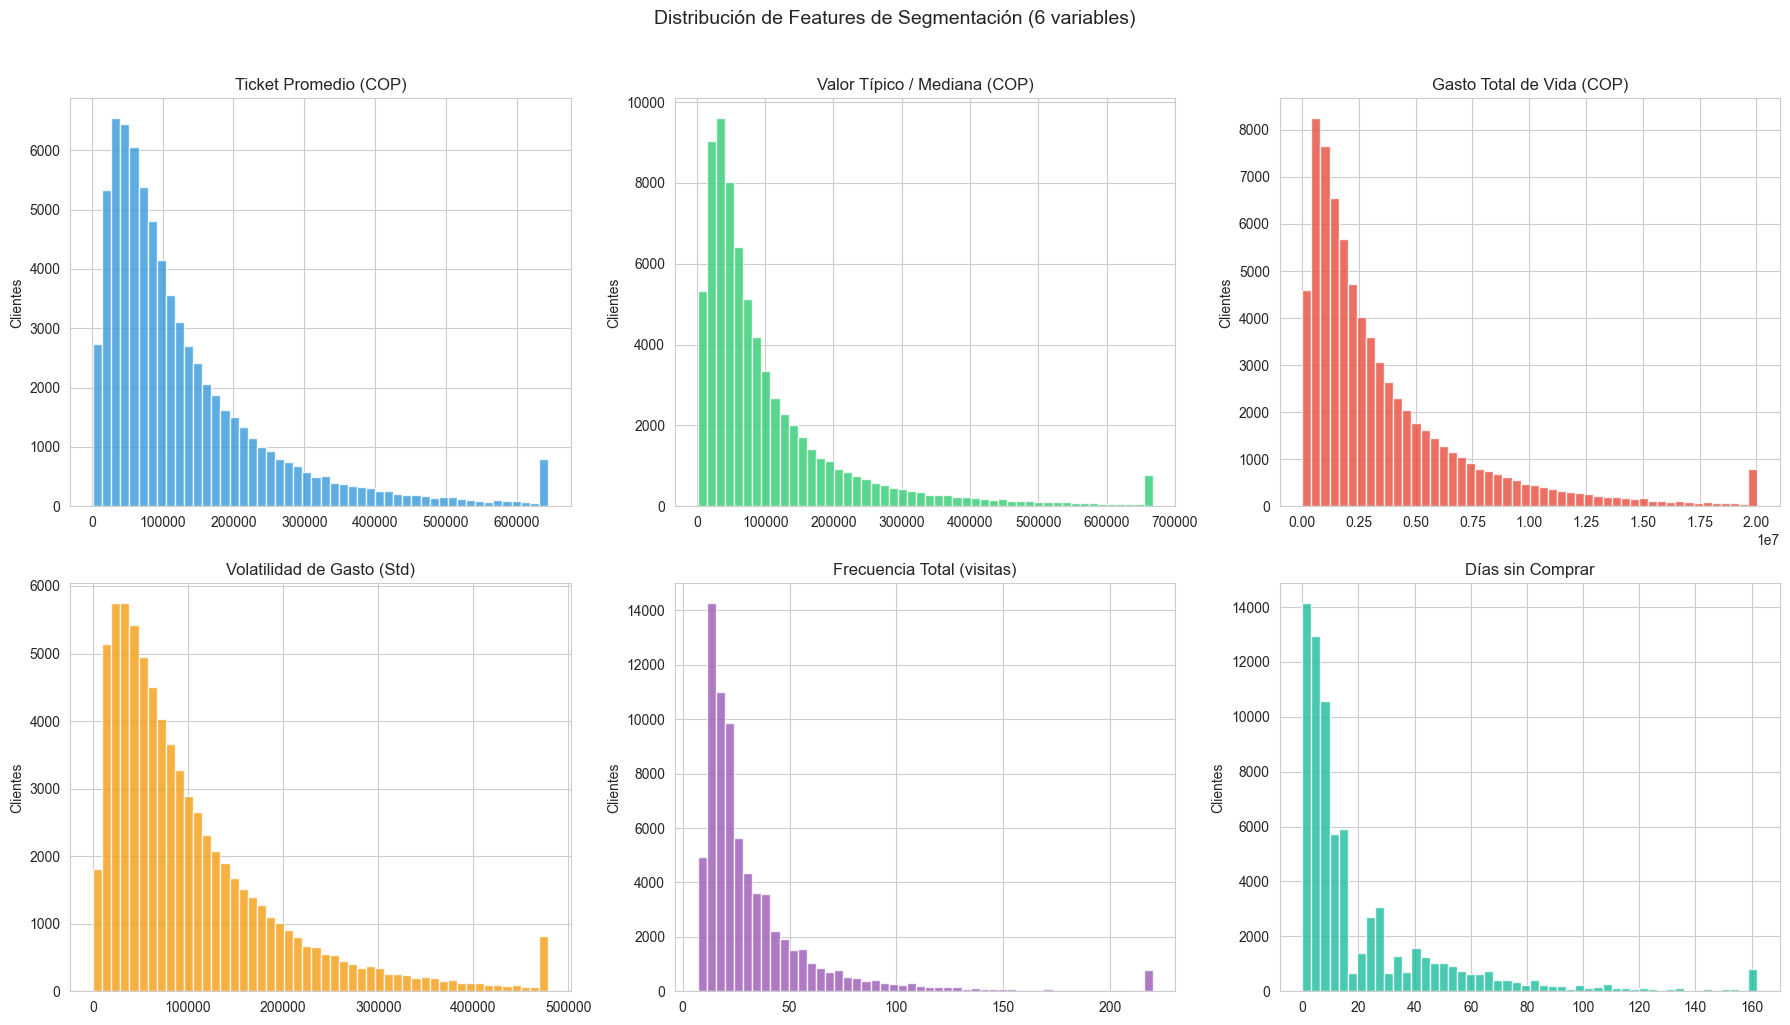

In [24]:
# Distribución de las 6 features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
titles = [
    "Ticket Promedio (COP)", "Valor Típico / Mediana (COP)",
    "Gasto Total de Vida (COP)", "Volatilidad de Gasto (Std)",
    "Frecuencia Total (visitas)", "Días sin Comprar",
]
colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12", "#9b59b6", "#1abc9c"]

for ax, col, title, color in zip(axes.flat, FEATURE_COLS, titles, colors):
    data = user_features[col].clip(upper=user_features[col].quantile(0.99))
    data.hist(bins=50, ax=ax, color=color, edgecolor="white", alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Clientes")

plt.suptitle("Distribución de Features de Segmentación (6 variables)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Clustering K-Means (k=4)

- StandardScaler para normalizar
- Selección de K: Método del Codo + Silhouette
- k=4 basado en el método del codo

  k=2 → silhouette=0.4892
  k=3 → silhouette=0.3902
  k=4 → silhouette=0.4274
  k=5 → silhouette=0.3938
  k=6 → silhouette=0.3528
  k=7 → silhouette=0.3439
  k=8 → silhouette=0.3577
  k=9 → silhouette=0.3362


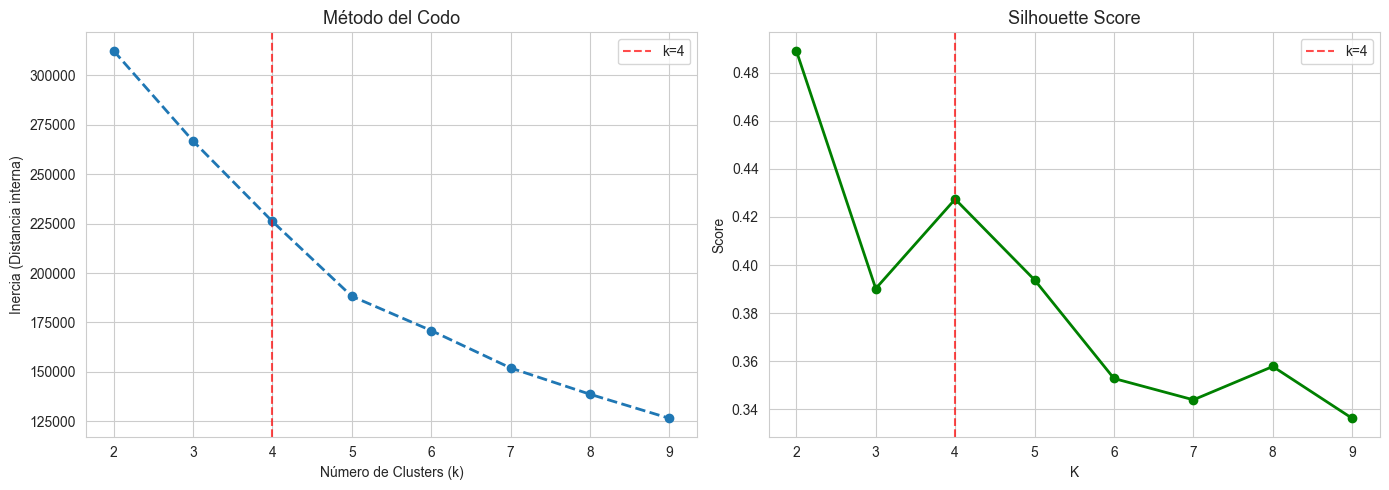

In [25]:
# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(user_features)
df_scaled = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=user_features.index)

# Selección de K
k_range = range(2, 10)
inertias = []
silhouettes = []
sample_size = min(5000, len(X_scaled))

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=sample_size)
    silhouettes.append(sil)
    print(f"  k={k} → silhouette={sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_range, inertias, marker="o", linewidth=2, linestyle="--")
ax1.axvline(N_CLUSTERS, color="red", linestyle="--", alpha=0.7, label=f"k={N_CLUSTERS}")
ax1.set_title("Método del Codo", fontsize=13)
ax1.set_xlabel("Número de Clusters (k)")
ax1.set_ylabel("Inercia (Distancia interna)")
ax1.legend()
ax1.grid(True)

ax2.plot(k_range, silhouettes, marker="o", color="green", linewidth=2)
ax2.axvline(N_CLUSTERS, color="red", linestyle="--", alpha=0.7, label=f"k={N_CLUSTERS}")
ax2.set_title("Silhouette Score", fontsize=13)
ax2.set_xlabel("K")
ax2.set_ylabel("Score")
ax2.legend()

plt.tight_layout()
plt.show()

In [26]:
# Entrenar K-Means con k=4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
user_features["cluster_id"] = kmeans.fit_predict(df_scaled)

sil_final = silhouette_score(X_scaled, user_features["cluster_id"], sample_size=sample_size)
print(f"K elegido: {N_CLUSTERS}")
print(f"Silhouette final: {sil_final:.4f}")

# Perfil de los grupos
perfil = user_features.groupby("cluster_id")[FEATURE_COLS].mean()
perfil["cantidad_usuarios"] = user_features["cluster_id"].value_counts().sort_index()

print("\n--- PERFIL DE LOS GRUPOS DETECTADOS ---")
display(perfil.round(0))

K elegido: 4
Silhouette final: 0.4235

--- PERFIL DE LOS GRUPOS DETECTADOS ---


,ticket_promedio,valor_tipico,gasto_total_vida,volatilidad_gasto,frecuencia_total,dias_sin_comprar,cantidad_usuarios
cluster_id,,,,,,,
0,389939.0,348790.0,9867958.0,286212.0,27.0,17.0,9956
1,84245.0,67060.0,1480742.0,68519.0,21.0,93.0,7799
2,50992.0,32666.0,9390490.0,59284.0,220.0,7.0,2112
3,93235.0,72108.0,2757440.0,78908.0,31.0,13.0,53649


## 5. Identificación y Perfilamiento de Segmentos

Asignación de nombres basada en centroides (como en el PDF):

| Grupo | Nombre | Ticket Promedio | Características |
|-------|--------|----------------|----------------|
| 1 | Reposición | ~$44k | Frecuencia alta, ticket bajo |
| 2 | Mercado Intermedio | ~$77k | Frecuencia media, riesgo de pérdida |
| 3 | Masa Crítica | ~$88k | Mayor volumen, foco principal |
| 4 | Ballenas | ~$372k | Minisupermercados, alto valor |

In [27]:
# Etiquetar clusters automáticamente
centroids = user_features.groupby("cluster_id")[FEATURE_COLS].mean()
cluster_sizes = user_features["cluster_id"].value_counts()

# Ballena: mayor ticket_promedio
ballena_id = centroids["ticket_promedio"].idxmax()
# Reposición: mayor frecuencia entre los no-ballena
reposicion_id = centroids.drop(ballena_id)["frecuencia_total"].idxmax()
# Masa crítica: mayor cantidad de clientes entre los restantes
remaining = [c for c in centroids.index if c not in [ballena_id, reposicion_id]]
masa_critica_id = cluster_sizes[remaining].idxmax()
# Mercado intermedio: el restante
intermedio_id = [c for c in remaining if c != masa_critica_id][0]

CLUSTER_NAMES = {
    reposicion_id: "Reposición",
    intermedio_id: "Mercado Intermedio",
    masa_critica_id: "Masa Crítica",
    ballena_id: "Ballenas",
}

# Grupo ordenado como en el PDF
GRUPO_ORDER = [reposicion_id, intermedio_id, masa_critica_id, ballena_id]
CLUSTER_TO_GRUPO = {cid: i + 1 for i, cid in enumerate(GRUPO_ORDER)}

user_features["nombre"] = user_features["cluster_id"].map(CLUSTER_NAMES)
user_features["grupo"] = user_features["cluster_id"].map(CLUSTER_TO_GRUPO)

# Resumen
print("Segmentos identificados:\n")
for cid in GRUPO_ORDER:
    n = (user_features["cluster_id"] == cid).sum()
    tp = centroids.loc[cid, "ticket_promedio"]
    freq = centroids.loc[cid, "frecuencia_total"]
    grupo = CLUSTER_TO_GRUPO[cid]
    print(f"  Grupo {grupo} - Cluster {cid}: \"{CLUSTER_NAMES[cid]}\"")
    print(f"    ~{n:,} usuarios | Ticket Promedio: ${tp:,.0f} | Frecuencia: {freq:.0f} visitas")
    print()

Segmentos identificados:

  Grupo 1 - Cluster 2: "Reposición"
    ~2,112 usuarios | Ticket Promedio: $50,992 | Frecuencia: 220 visitas

  Grupo 2 - Cluster 1: "Mercado Intermedio"
    ~7,799 usuarios | Ticket Promedio: $84,245 | Frecuencia: 21 visitas

  Grupo 3 - Cluster 3: "Masa Crítica"
    ~53,649 usuarios | Ticket Promedio: $93,235 | Frecuencia: 31 visitas

  Grupo 4 - Cluster 0: "Ballenas"
    ~9,956 usuarios | Ticket Promedio: $389,939 | Frecuencia: 27 visitas



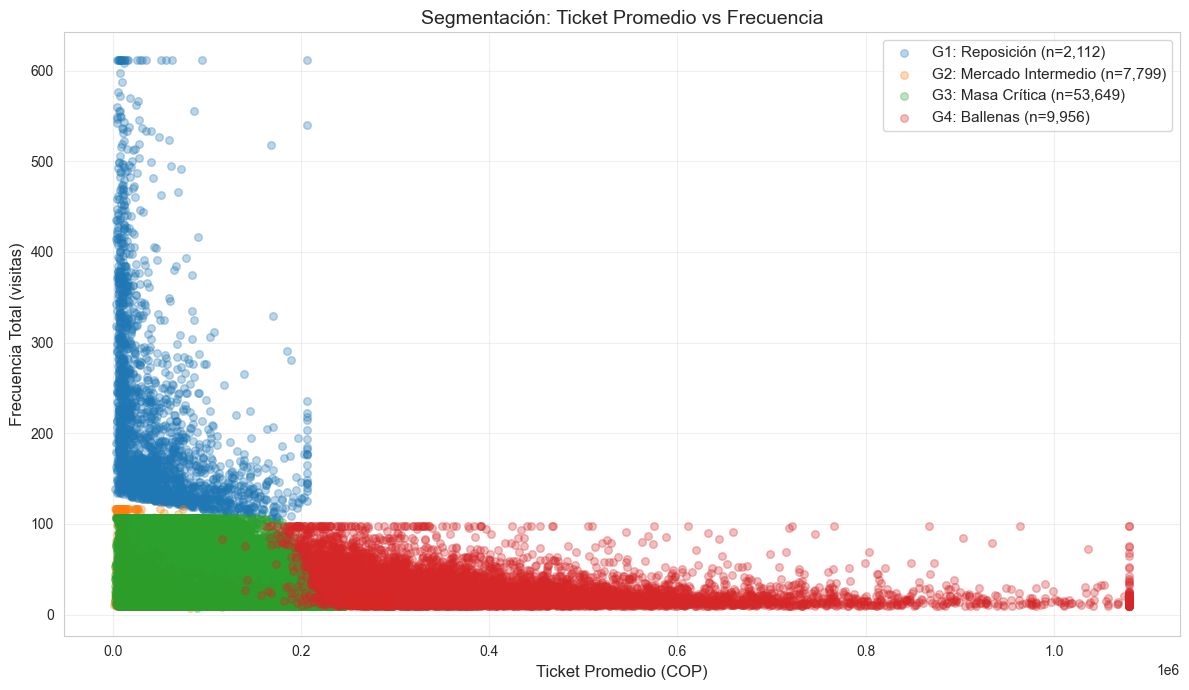

In [28]:
# Scatter: Ticket Promedio vs Frecuencia (coloreado por cluster)
fig, ax = plt.subplots(figsize=(12, 7))

for cid in GRUPO_ORDER:
    mask = user_features["cluster_id"] == cid
    data = user_features[mask]
    grupo = CLUSTER_TO_GRUPO[cid]
    nombre = CLUSTER_NAMES[cid]
    ax.scatter(
        data["ticket_promedio"].clip(upper=data["ticket_promedio"].quantile(0.99)),
        data["frecuencia_total"].clip(upper=data["frecuencia_total"].quantile(0.99)),
        alpha=0.3,
        label=f"G{grupo}: {nombre} (n={len(data):,})",
        s=30,
    )

ax.set_xlabel("Ticket Promedio (COP)", fontsize=12)
ax.set_ylabel("Frecuencia Total (visitas)", fontsize=12)
ax.set_title("Segmentación: Ticket Promedio vs Frecuencia", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Análisis de Evolución Mensual

Comportamiento de cada cluster a lo largo del tiempo:
- **Barras**: Frecuencia promedio de visitas por mes
- **Líneas**: Valor medio y mediana del ticket

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_ol

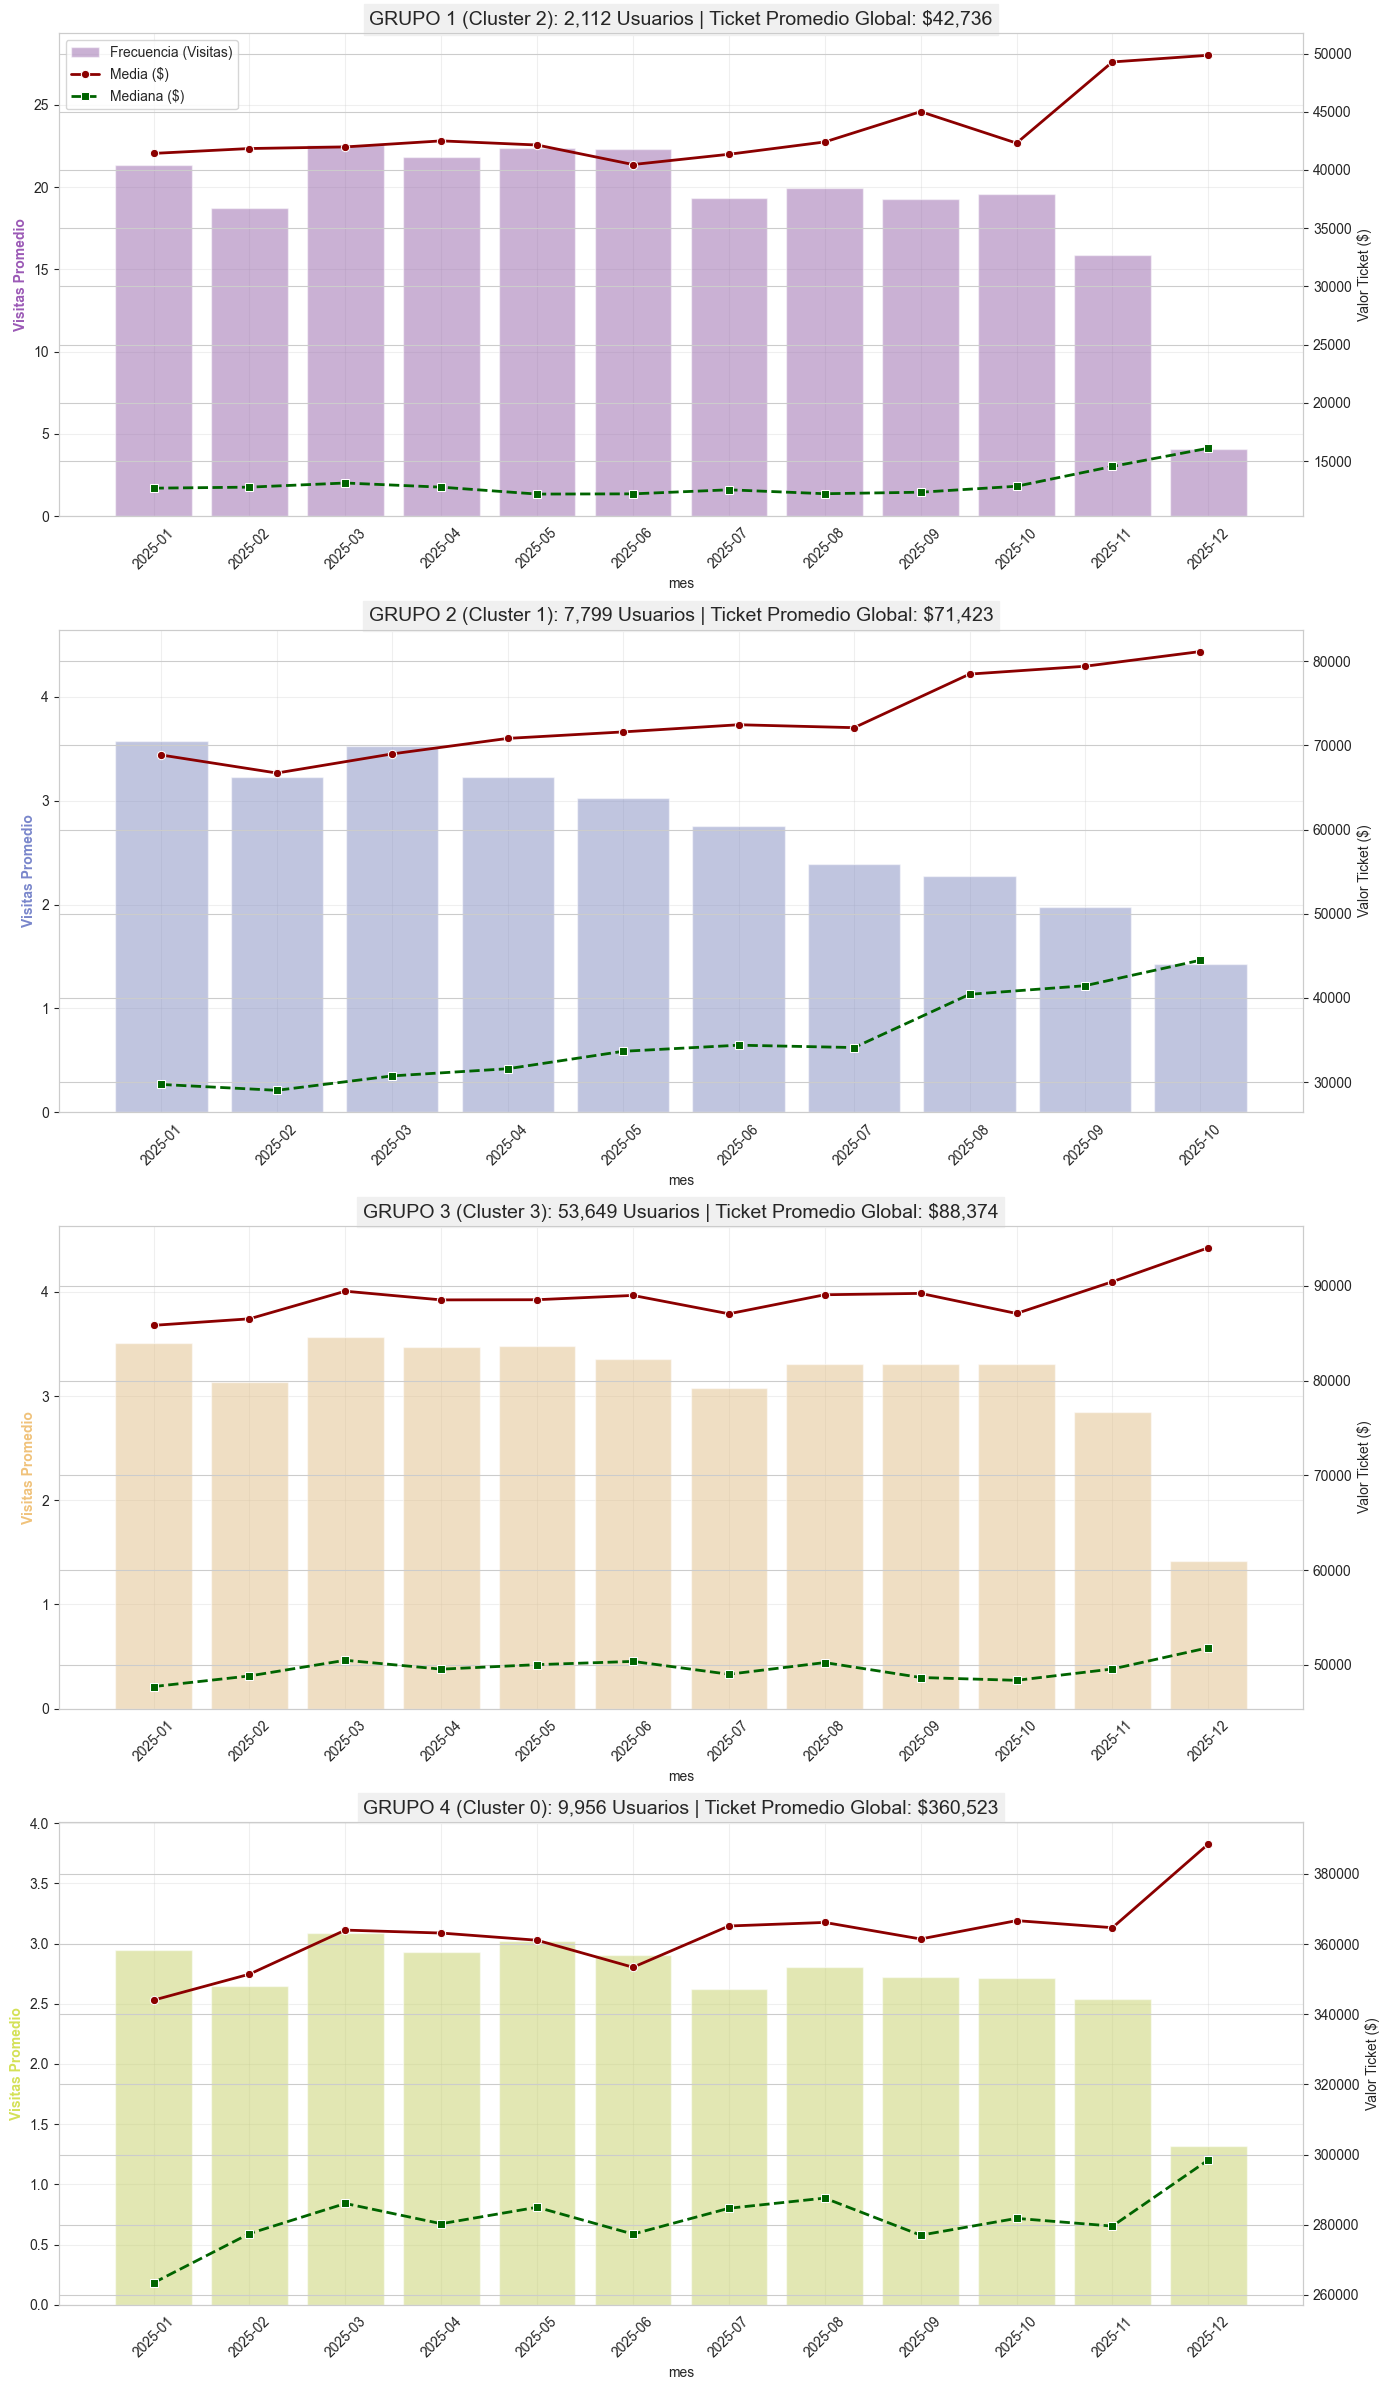

In [29]:
# Unir tickets con cluster_id
df_tickets_cl = df_tickets.merge(
    user_features[["cluster_id", "nombre", "grupo"]],
    left_on="user_id", right_index=True, how="inner",
)
df_tickets_cl["mes"] = df_tickets_cl["date_sale"].dt.to_period("M")

# Ordenar clusters por ticket promedio (como en eda.ipynb)
orden_clusters = (
    user_features.groupby("cluster_id")["ticket_promedio"]
    .mean().sort_values().index
)

# Métricas mensuales por cluster
fig, axes = plt.subplots(N_CLUSTERS, 1, figsize=(14, 6 * N_CLUSTERS))

for i, cid in enumerate(orden_clusters):
    ax = axes[i]
    cl_data = df_tickets_cl[df_tickets_cl["cluster_id"] == cid]

    metrics = cl_data.groupby("mes").agg(
        total_tickets=("tiket_id", "count"),
        usuarios_unicos=("user_id", "nunique"),
        valor_media=("tiket_price", "mean"),
        valor_mediana=("tiket_price", "median"),
    )
    metrics["frecuencia_promedio"] = metrics["total_tickets"] / metrics["usuarios_unicos"]
    metrics.index = metrics.index.astype(str)

    n_usuarios = cl_data["user_id"].nunique()
    avg_ticket = cl_data["tiket_price"].mean()
    nombre = CLUSTER_NAMES.get(cid, f"Cluster {cid}")
    grupo = CLUSTER_TO_GRUPO.get(cid, "?")
    color = CLUSTER_COLORS_LIST[i % len(CLUSTER_COLORS_LIST)]

    # Barras: frecuencia
    sns.barplot(
        data=metrics, x=metrics.index, y="frecuencia_promedio",
        alpha=0.5, color=color, ax=ax, label="Frecuencia (Visitas)",
    )
    ax.set_ylabel("Visitas Promedio", color=color, fontweight="bold")
    ax.set_ylim(0, metrics["frecuencia_promedio"].max() * 1.3)

    # Líneas: media y mediana
    ax2 = ax.twinx()
    sns.lineplot(
        data=metrics, x=metrics.index, y="valor_media",
        marker="o", color="darkred", linewidth=2, ax=ax2, label="Media ($)",
    )
    sns.lineplot(
        data=metrics, x=metrics.index, y="valor_mediana",
        marker="s", color="darkgreen", linestyle="--", linewidth=2,
        ax=ax2, label="Mediana ($)",
    )
    ax2.set_ylabel("Valor Ticket ($)")

    ax.set_title(
        f"GRUPO {grupo} (Cluster {cid}): {n_usuarios:,} Usuarios | "
        f"Ticket Promedio Global: ${avg_ticket:,.0f}",
        fontsize=14, backgroundcolor="#f0f0f0",
    )
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

    if i == 0:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    else:
        ax.get_legend().remove() if ax.get_legend() else None
        ax2.get_legend().remove() if ax2.get_legend() else None

plt.tight_layout()
plt.show()

## 7. Análisis de Canasta "De Combate"

Productos con mayor **penetración** (% de tickets que los contienen) por cluster.
Son los "precios bandera" — cualquier cambio se nota en todos los tickets.

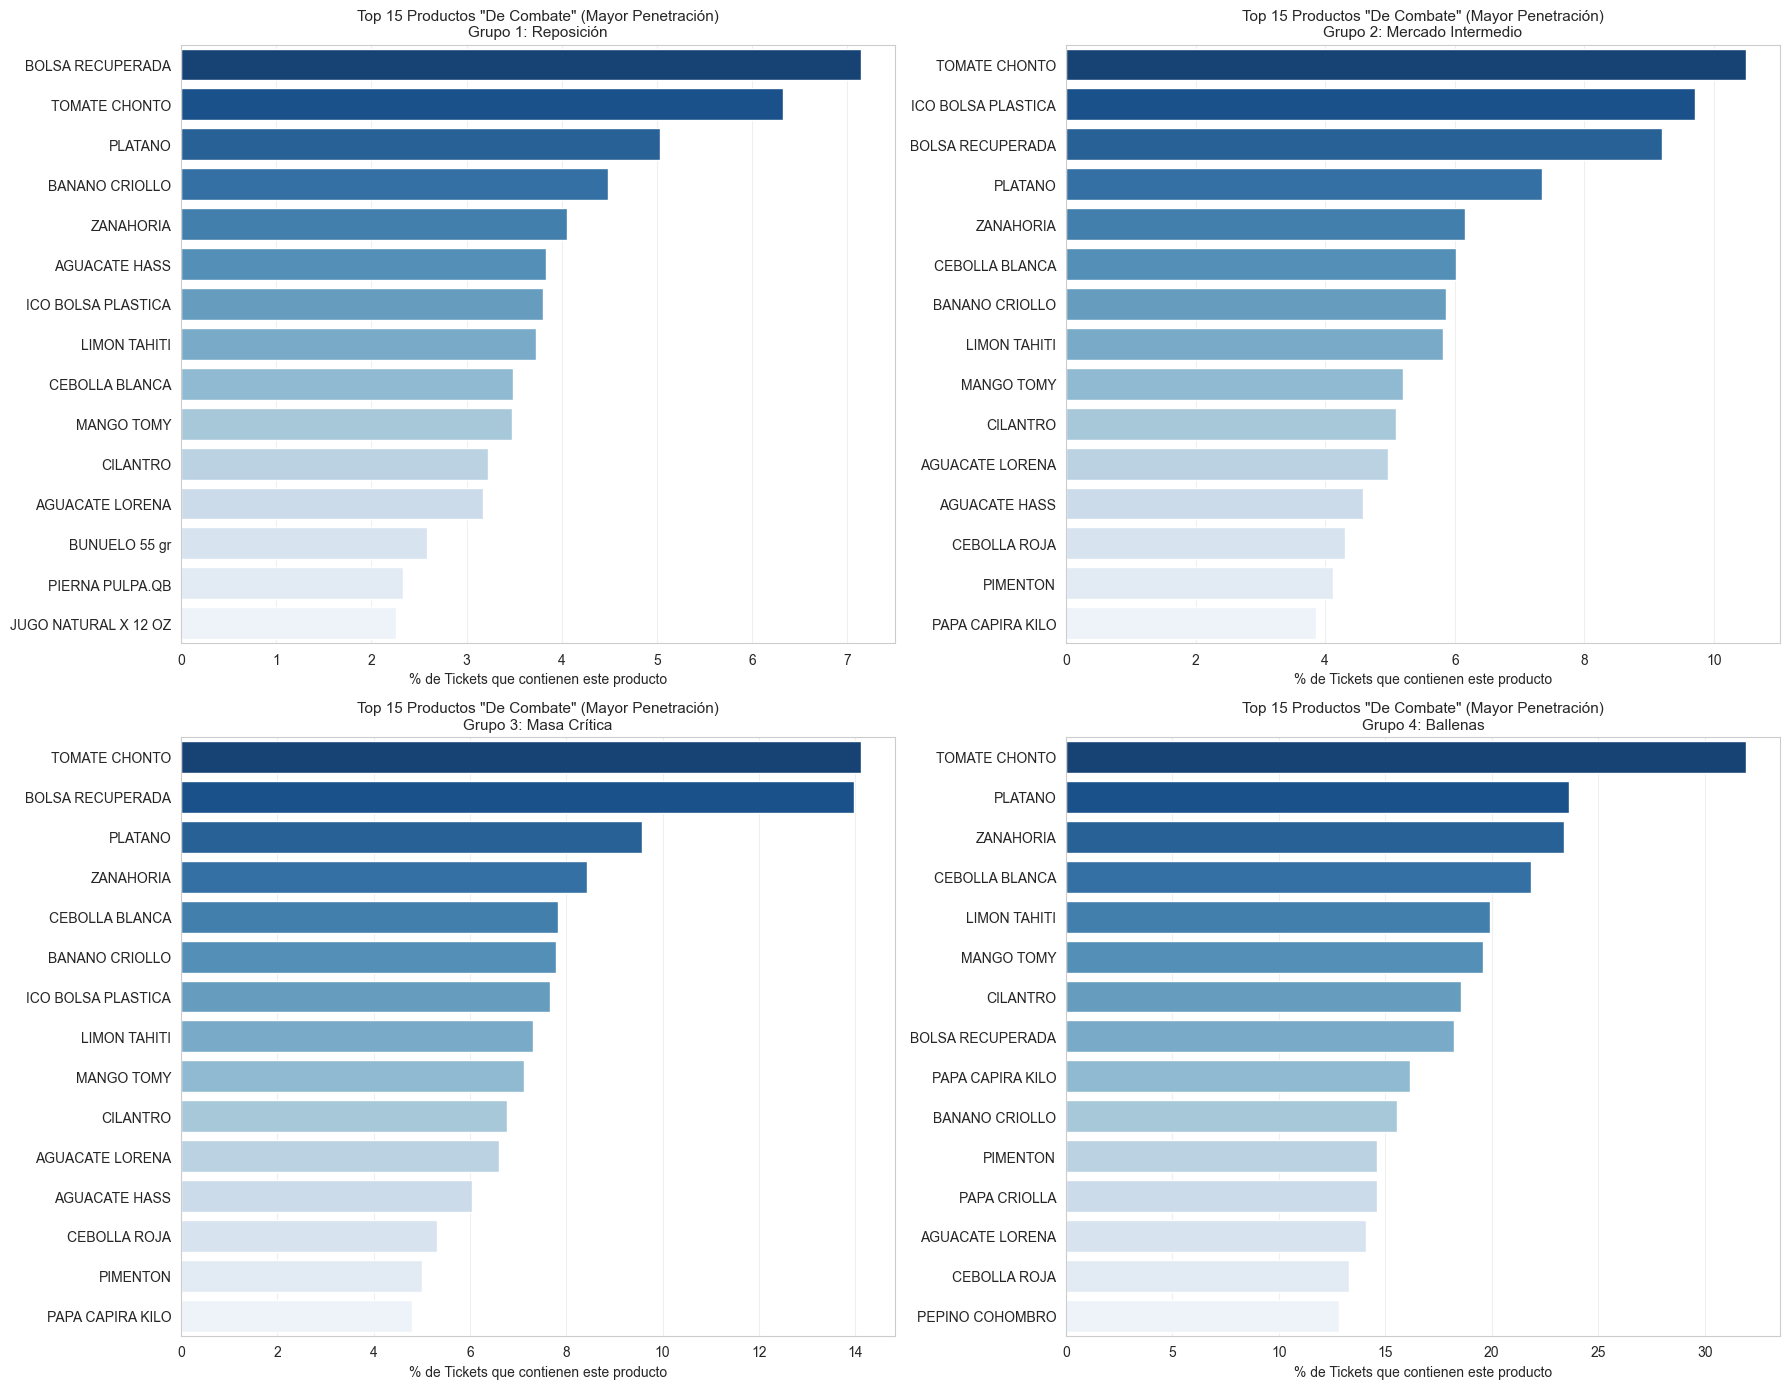

In [30]:
# Unir ventas detalladas con clusters
df_full = df_master.merge(
    user_features[["cluster_id", "nombre", "grupo"]],
    left_on="user_id", right_index=True, how="inner",
)

# Top 15 productos por penetración en cada cluster
n_top = 15
top_per_cluster = {}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, cid in zip(axes.flat, GRUPO_ORDER):
    seg = df_full[df_full["cluster_id"] == cid]
    total_tickets = seg["tiket_id"].nunique()

    prod_freq = (
        seg.groupby("product_name")["tiket_id"]
        .nunique()
        .sort_values(ascending=False)
        .head(n_top)
    )
    penetration = prod_freq / total_tickets * 100
    top_per_cluster[cid] = set(prod_freq.index)

    nombre = CLUSTER_NAMES[cid]
    grupo = CLUSTER_TO_GRUPO[cid]

    sns.barplot(
        x=penetration.values, y=penetration.index,
        palette="Blues_r", ax=ax,
    )
    ax.set_title(f'Top {n_top} Productos "De Combate" (Mayor Penetración)\n'
                 f"Grupo {grupo}: {nombre}", fontsize=11)
    ax.set_xlabel("% de Tickets que contienen este producto")
    ax.set_ylabel("")
    ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# Productos Core (aparecen en top de TODOS los clusters)
productos_core = set.intersection(*top_per_cluster.values())
print("Productos Core (Alta Penetración en todos los clusters):")
for p in sorted(productos_core):
    print(f"  - {p}")

# Productos Premium (solo en clusters de mayor valor)
high_val = {ballena_id, intermedio_id}
low_val = {c for c in GRUPO_ORDER if c not in high_val}
premium_only = set.union(*[top_per_cluster[c] for c in high_val]) - \
               set.union(*[top_per_cluster[c] for c in low_val])
if premium_only:
    print(f"\nProductos Premium (solo en clusters de mayor valor):")
    for p in sorted(premium_only):
        print(f"  - {p}")

Productos Core (Alta Penetración en todos los clusters):
  - AGUACATE LORENA
  - BANANO CRIOLLO
  - BOLSA RECUPERADA
  - CEBOLLA BLANCA
  - CILANTRO
  - LIMON TAHITI
  - MANGO TOMY
  - PLATANO
  - TOMATE CHONTO
  - ZANAHORIA

Productos Premium (solo en clusters de mayor valor):
  - PAPA CRIOLLA
  - PEPINO COHOMBRO


## 8. Ciclo de Supervivencia (Gasto Durante el Mes)

Patrón de gasto por día del mes — muestra dependencia del ciclo de nómina/quincena.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_ol

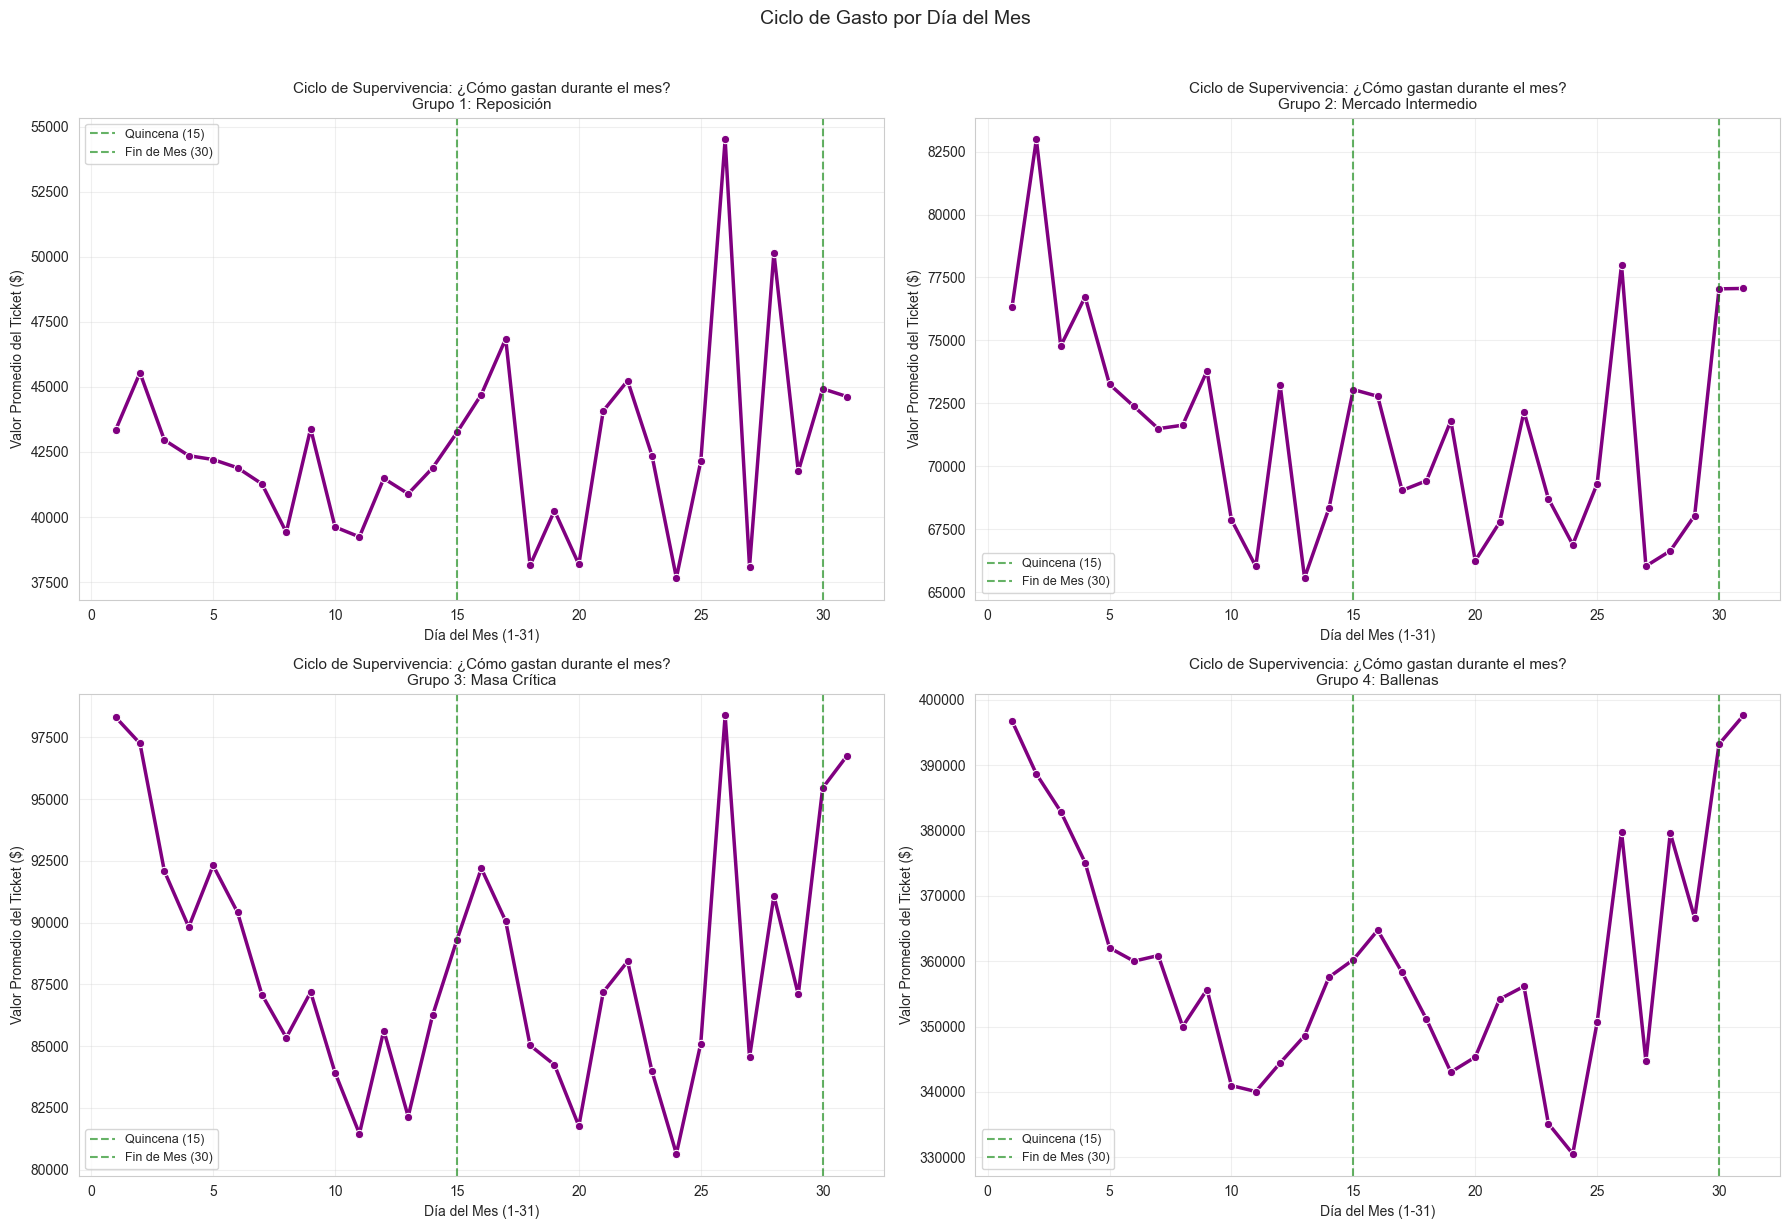

In [32]:
# Gasto promedio por día del mes, por cluster
df_tickets_cl["dia_mes"] = df_tickets_cl["date_sale"].dt.day

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, cid in zip(axes.flat, GRUPO_ORDER):
    data = df_tickets_cl[df_tickets_cl["cluster_id"] == cid]
    gasto_dia = data.groupby("dia_mes")["tiket_price"].mean()
    nombre = CLUSTER_NAMES[cid]
    grupo = CLUSTER_TO_GRUPO[cid]

    sns.lineplot(x=gasto_dia.index, y=gasto_dia.values, marker="o",
                 color="purple", linewidth=2.5, ax=ax)
    ax.set_title(f"Ciclo de Supervivencia: ¿Cómo gastan durante el mes?\n"
                 f"Grupo {grupo}: {nombre}", fontsize=11)
    ax.set_xlabel("Día del Mes (1-31)")
    ax.set_ylabel("Valor Promedio del Ticket ($)")
    ax.axvline(15, color="green", linestyle="--", alpha=0.6, label="Quincena (15)")
    ax.axvline(30, color="green", linestyle="--", alpha=0.6, label="Fin de Mes (30)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Ciclo de Gasto por Día del Mes", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

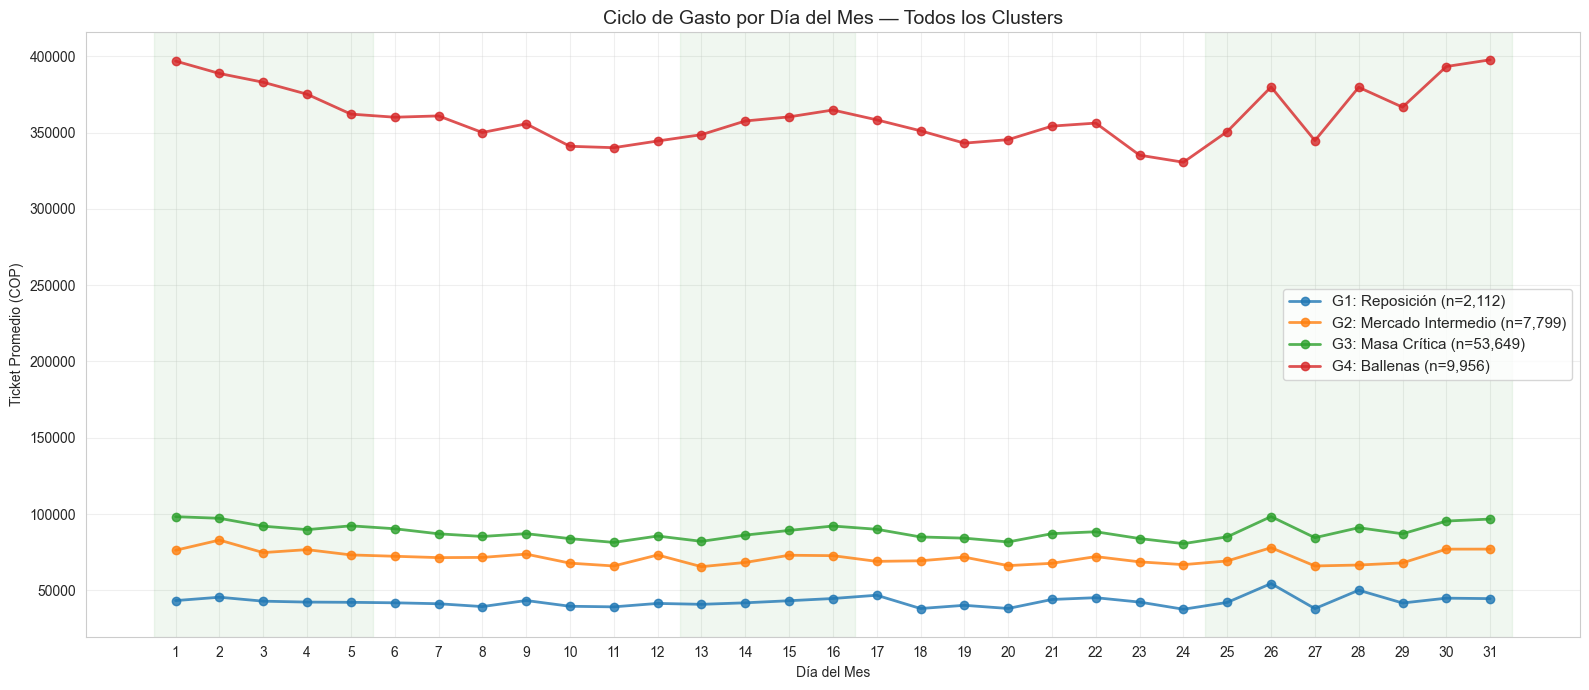


Patrón General Identificado:
  1. Días 1-5: Pico fuerte al inicio de mes (pago de nómina)
  2. Días 6-15: Caída progresiva hacia la mitad del mes
  3. Días 15-24: Valle — compras de 'supervivencia'
  4. Días 25-30: Rebote marcado (pago de nómina nuevamente)


In [33]:
# Patrón general: todos los clusters juntos
fig, ax = plt.subplots(figsize=(16, 7))

for cid in GRUPO_ORDER:
    data = df_tickets_cl[df_tickets_cl["cluster_id"] == cid]
    gasto_dia = data.groupby("dia_mes")["tiket_price"].mean()
    nombre = CLUSTER_NAMES[cid]
    grupo = CLUSTER_TO_GRUPO[cid]
    n = (user_features["cluster_id"] == cid).sum()
    ax.plot(gasto_dia.index, gasto_dia.values, marker="o", linewidth=2,
            label=f"G{grupo}: {nombre} (n={n:,})", alpha=0.8)

for x0, x1 in [(0.5, 5.5), (12.5, 16.5), (24.5, 31.5)]:
    ax.axvspan(x0, x1, color="green", alpha=0.06)

ax.set_title("Ciclo de Gasto por Día del Mes — Todos los Clusters", fontsize=14)
ax.set_xlabel("Día del Mes")
ax.set_ylabel("Ticket Promedio (COP)")
ax.set_xticks(range(1, 32))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPatrón General Identificado:")
print("  1. Días 1-5: Pico fuerte al inicio de mes (pago de nómina)")
print("  2. Días 6-15: Caída progresiva hacia la mitad del mes")
print("  3. Días 15-24: Valle — compras de 'supervivencia'")
print("  4. Días 25-30: Rebote marcado (pago de nómina nuevamente)")

## 9. Análisis de Clientes en Caída

**Metodología:** Se comparan dos periodos del año 2025:
- **P1 (Ene-Jul):** Periodo "bueno" (meses 1-7)
- **P2 (Ago-Dic):** Periodo reciente (meses 8-12)

Se detectan clientes que:
1. En P1 gastaban **≥ mediana global** de su segmento
2. En P2 gastan **< mediana global**
3. Tienen actividad en ambos periodos

In [34]:
# Periodos: Ene-Jul vs Ago-Dic (como en el PDF)
MESES_P1 = list(range(1, 8))   # Ene–Jul
MESES_P2 = list(range(8, 13))  # Ago–Dic

def detectar_clientes_caida(df_cluster_tickets, meses_p1, meses_p2):
    """Detecta clientes que cayeron de P1 a P2."""
    df = df_cluster_tickets.copy()
    df["mes_num"] = df["date_sale"].dt.month

    # Mediana global del cluster
    mediana_global = df["tiket_price"].median()

    # Pivot: usuario x mes → ticket promedio
    pivot = df.pivot_table(
        index="user_id", columns="mes_num",
        values="tiket_price", aggfunc="mean",
    )
    pivot = pivot.reindex(columns=range(1, 13))

    # Promedios por periodo (mediana de los meses)
    pivot["promedio_P1"] = pivot[meses_p1].median(axis=1)
    pivot["promedio_P2"] = pivot[meses_p2].median(axis=1)

    # Condiciones de caída
    caidos = pivot[
        (pivot["promedio_P1"] >= mediana_global) &
        (pivot["promedio_P2"] < mediana_global) &
        pivot["promedio_P1"].notnull() &
        pivot["promedio_P2"].notnull()
    ].copy()
    caidos["delta_caida"] = caidos["promedio_P1"] - caidos["promedio_P2"]

    # Trayectoria promedio de los caídos
    if len(caidos) > 0:
        df_plot = df[df["user_id"].isin(caidos.index)]
        trend = df_plot.groupby("mes_num")["tiket_price"].mean().reindex(range(1, 13))
    else:
        trend = pd.Series(index=range(1, 13), dtype=float)

    return caidos, trend, mediana_global


# Preparar tickets únicos por cluster
cluster_tickets = {}
for cid in GRUPO_ORDER:
    cluster_tickets[cid] = df_tickets_cl[df_tickets_cl["cluster_id"] == cid].copy()

# Detectar caídos por cluster
resultados_caida = {}
print("Resultados por Cluster:")
print(f"{'Cluster':<12} {'Clientes Caídos':>16} {'Mediana Global':>15} {'Impacto'}")
print("-" * 70)

for cid in GRUPO_ORDER:
    caidos, trend, mediana = detectar_clientes_caida(
        cluster_tickets[cid], MESES_P1, MESES_P2
    )
    resultados_caida[cid] = {"caidos": caidos, "trend": trend, "mediana": mediana}

    nombre = CLUSTER_NAMES[cid]
    impacto_map = {
        "Masa Crítica": "CRÍTICO - Masa crítica",
        "Ballenas": "MUY ALTO - Ballenas",
        "Mercado Intermedio": "Alto - Segmento intermedio",
        "Reposición": "Bajo - Segmento bajo",
    }
    impacto = impacto_map.get(nombre, "")
    print(f"Cluster {cid:<5} {len(caidos):>16,} ${mediana:>14,.0f} {impacto}")

total_caidos = sum(len(r["caidos"]) for r in resultados_caida.values())
print(f"\nTotal clientes en caída: {total_caidos:,}")

Resultados por Cluster:
Cluster       Clientes Caídos  Mediana Global Impacto
----------------------------------------------------------------------
Cluster 2                   53 $        12,728 Bajo - Segmento bajo
Cluster 1                  709 $        33,082 Alto - Segmento intermedio
Cluster 3                4,703 $        49,408 CRÍTICO - Masa crítica
Cluster 0                1,775 $       280,392 MUY ALTO - Ballenas

Total clientes en caída: 7,240


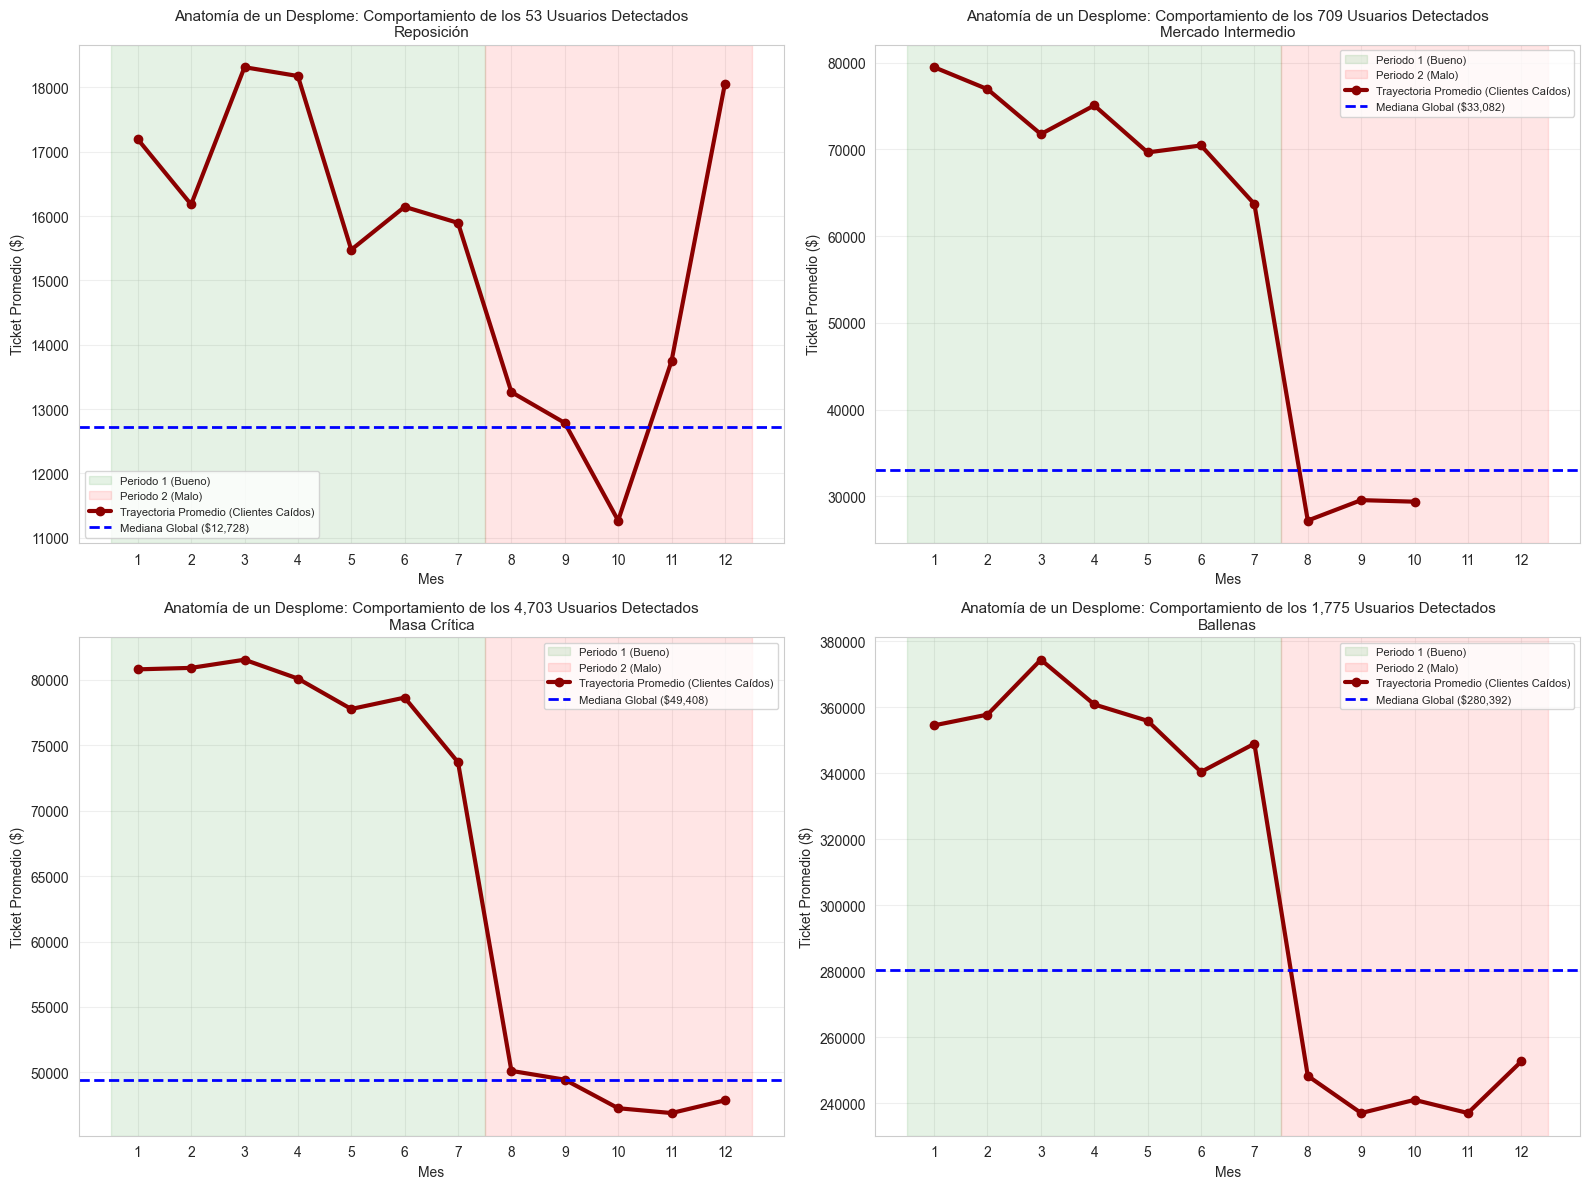


Hallazgos Críticos:
  1. El quiebre es en agosto (mes 8) en todos los segmentos
  2. El ticket promedio se desploma y no se recupera
  3. Los clientes no desaparecen, siguen comprando pero gastan mucho menos


In [35]:
# Anatomía del desplome: trayectoria mensual de los clientes caídos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, cid in zip(axes.flat, GRUPO_ORDER):
    res = resultados_caida[cid]
    trend = res["trend"]
    mediana = res["mediana"]
    n_caidos = len(res["caidos"])
    nombre = CLUSTER_NAMES[cid]

    if n_caidos == 0 or trend.isna().all():
        ax.set_title(f"{nombre} (sin clientes caídos)")
        continue

    # Zonas P1 (verde) y P2 (rojo)
    ax.axvspan(0.5, 7.5, color="green", alpha=0.1, label="Periodo 1 (Bueno)")
    ax.axvspan(7.5, 12.5, color="red", alpha=0.1, label="Periodo 2 (Malo)")

    # Trayectoria
    ax.plot(trend.index, trend.values, color="darkred", marker="o",
            linewidth=3, label="Trayectoria Promedio (Clientes Caídos)")
    ax.axhline(mediana, color="blue", linestyle="--", linewidth=2,
               label=f"Mediana Global (${mediana:,.0f})")

    ax.set_title(
        f"Anatomía de un Desplome: Comportamiento de los {n_caidos:,} Usuarios Detectados\n"
        f"{nombre}",
        fontsize=11,
    )
    ax.set_xlabel("Mes")
    ax.set_ylabel("Ticket Promedio ($)")
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHallazgos Críticos:")
print("  1. El quiebre es en agosto (mes 8) en todos los segmentos")
print("  2. El ticket promedio se desploma y no se recupera")
print("  3. Los clientes no desaparecen, siguen comprando pero gastan mucho menos")

## 10. Productos que Están Recortando los Clientes ("Efecto Recorte")

Comparación del consumo promedio mensual por usuario entre P1 y P2.
- `avg_px = (total unidades) / (n_meses_periodo × n_usuarios)`
- Visualización tipo dumbbell (antes vs después)

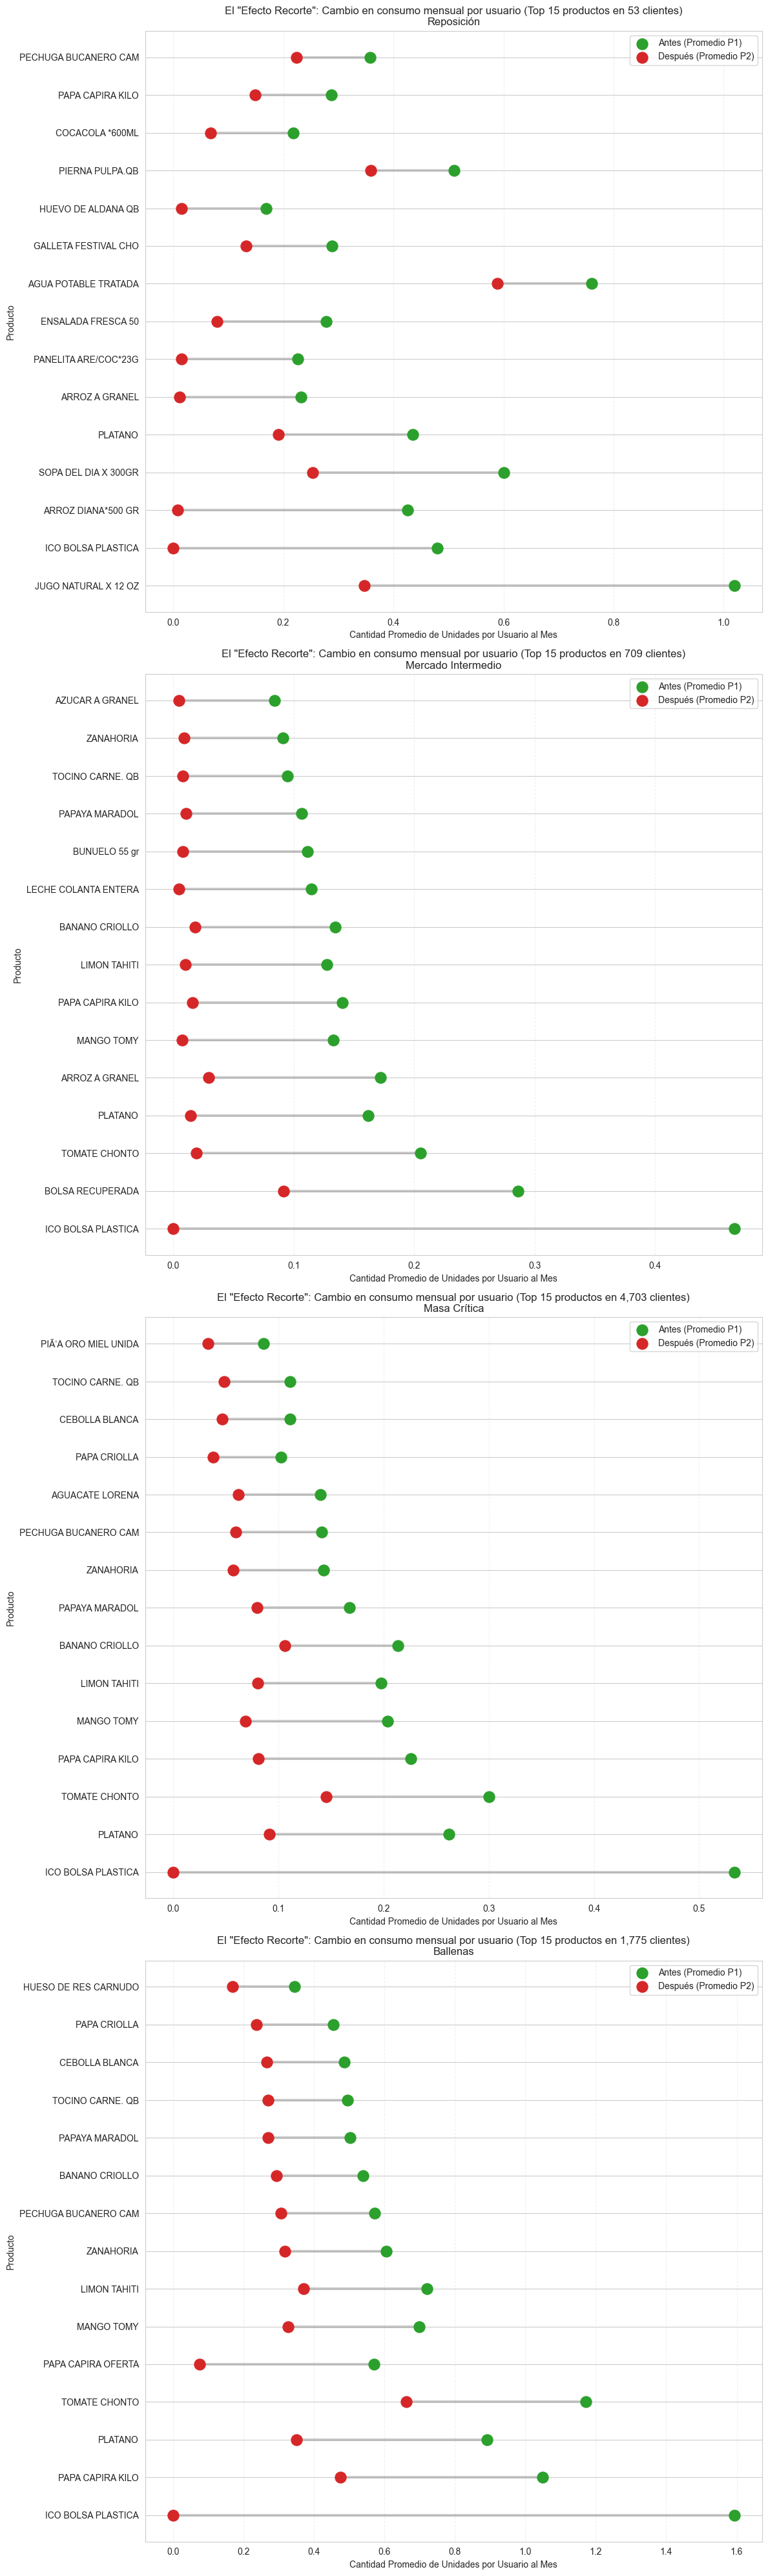

In [36]:
def preparar_cambio_productos(df_master_cluster, clientes_ids, meses_p1, meses_p2, top_n=15):
    """Calcula cambio en consumo promedio mensual por producto."""
    df = df_master_cluster[df_master_cluster["user_id"].isin(clientes_ids)].copy()
    df["mes"] = df["date_sale"].dt.month
    n_usuarios = len(set(clientes_ids))
    n_meses_p1 = len(meses_p1)
    n_meses_p2 = len(meses_p2)

    p1 = df[df["mes"].isin(meses_p1)].groupby("product_name")["amount"].sum().reset_index()
    p1["avg_p1"] = p1["amount"] / (n_meses_p1 * n_usuarios)

    p2 = df[df["mes"].isin(meses_p2)].groupby("product_name")["amount"].sum().reset_index()
    p2["avg_p2"] = p2["amount"] / (n_meses_p2 * n_usuarios)

    data = pd.merge(
        p1[["product_name", "avg_p1"]], p2[["product_name", "avg_p2"]],
        on="product_name", how="outer",
    ).fillna(0)
    data["caida"] = data["avg_p1"] - data["avg_p2"]
    top = data.sort_values("caida", ascending=False).head(top_n)

    return top, n_usuarios


# Dumbbell charts por cluster
fig, axes = plt.subplots(len(GRUPO_ORDER), 1, figsize=(12, 10 * len(GRUPO_ORDER)))

for ax, cid in zip(axes, GRUPO_ORDER):
    caidos = resultados_caida[cid]["caidos"]
    if len(caidos) == 0:
        ax.set_visible(False)
        continue

    seg_master = df_full[df_full["cluster_id"] == cid]
    top_plot, n_us = preparar_cambio_productos(
        seg_master, caidos.index, MESES_P1, MESES_P2, top_n=15,
    )
    nombre = CLUSTER_NAMES[cid]

    # Dumbbell
    ax.hlines(
        y=top_plot["product_name"], xmin=top_plot["avg_p2"], xmax=top_plot["avg_p1"],
        color="gray", alpha=0.4, linewidth=3,
    )
    ax.scatter(top_plot["avg_p1"], top_plot["product_name"],
               color="#2ca02c", s=150, zorder=3, label="Antes (Promedio P1)")
    ax.scatter(top_plot["avg_p2"], top_plot["product_name"],
               color="#d62728", s=150, zorder=3, label="Después (Promedio P2)")

    ax.set_title(
        f'El "Efecto Recorte": Cambio en consumo mensual por usuario '
        f'(Top 15 productos en {n_us:,} clientes)\n{nombre}',
        fontsize=12,
    )
    ax.set_xlabel("Cantidad Promedio de Unidades por Usuario al Mes")
    ax.set_ylabel("Producto")
    ax.legend(loc="upper right")
    ax.grid(True, axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

In [37]:
# Categorías más afectadas (resumen)
print("Categorías Más Afectadas (en todos los segmentos):\n")
print("1. Proteínas y Lácteos (Mayor Reducción):")
print("   Pollo (pechuga/pierna), Tocino, Quesos, Leche, Tabla QB\n")
print("2. Frutas y Verduras de Valor:")
print("   Tomate chonto, Papa (capira), Plátano, Banano, Aguacate, Cítricos\n")
print("3. Productos de conveniencia:")
print("   Bolsas plásticas, Bolsas recuperadas\n")
print("Interpretación:")
print("  - Los clientes priorizan productos básicos y recortan:")
print("    Proteínas (más costosos), Frutas/verduras premium, Conveniencia")

Categorías Más Afectadas (en todos los segmentos):

1. Proteínas y Lácteos (Mayor Reducción):
   Pollo (pechuga/pierna), Tocino, Quesos, Leche, Tabla QB

2. Frutas y Verduras de Valor:
   Tomate chonto, Papa (capira), Plátano, Banano, Aguacate, Cítricos

3. Productos de conveniencia:
   Bolsas plásticas, Bolsas recuperadas

Interpretación:
  - Los clientes priorizan productos básicos y recortan:
    Proteínas (más costosos), Frutas/verduras premium, Conveniencia


## 11. Resumen y Recomendaciones Estratégicas

### Hallazgos Principales

1. **4 segmentos** claramente diferenciados por comportamiento de compra
2. **Ciclo de nómina** visible en todos los clusters (picos días 1-5 y 25-30)
3. **Quiebre en agosto (mes 8)** — clientes caídos en todos los segmentos
4. **Efecto recorte**: proteínas, frutas/verduras premium y conveniencia

### Recomendaciones por Cluster

| Cluster | Estrategia | Acciones |
|---------|-----------|----------|
| **Reposición** | Incremento de ticket | Combos de "mercado completo", venta cruzada |
| **Mercado Intermedio** | Recuperación de perdidos | Campañas de reactivación, beneficios por ticket mínimo |
| **Masa Crítica** | Cross-sell y up-sell | Recomendaciones complementarias, retención de 11k caídos |
| **Ballenas** | Servicio VIP | Descuentos por volumen, surtido garantizado |

### Ventanas de Acción

- **Días 1-5 y 25-30**: Subir ticket promedio (canastas completas, cross-sell premium)
- **Días 15-24**: Mantener frecuencia (promociones productos básicos)

In [38]:
# Resumen final
print("=" * 60)
print("RESUMEN DE SEGMENTACIÓN (k=4)")
print("=" * 60)

for cid in GRUPO_ORDER:
    nombre = CLUSTER_NAMES[cid]
    grupo = CLUSTER_TO_GRUPO[cid]
    n = (user_features["cluster_id"] == cid).sum()
    tp = user_features.loc[user_features["cluster_id"] == cid, "ticket_promedio"].mean()
    n_caidos = len(resultados_caida[cid]["caidos"])
    mediana = resultados_caida[cid]["mediana"]

    print(f"\nGrupo {grupo} - Cluster {cid}: {nombre}")
    print(f"  Clientes:        {n:>10,}")
    print(f"  Ticket promedio: ${tp:>12,.0f}")
    print(f"  Mediana global:  ${mediana:>12,.0f}")
    print(f"  Clientes caídos: {n_caidos:>10,} ({n_caidos/n*100:.1f}%)")

total_users = len(user_features)
total_caidos = sum(len(r["caidos"]) for r in resultados_caida.values())
print(f"\n{'=' * 60}")
print(f"Total clientes: {total_users:,}")
print(f"Total en caída: {total_caidos:,} ({total_caidos/total_users*100:.1f}%)")

RESUMEN DE SEGMENTACIÓN (k=4)

Grupo 1 - Cluster 2: Reposición
  Clientes:             2,112
  Ticket promedio: $      50,992
  Mediana global:  $      12,728
  Clientes caídos:         53 (2.5%)

Grupo 2 - Cluster 1: Mercado Intermedio
  Clientes:             7,799
  Ticket promedio: $      84,245
  Mediana global:  $      33,082
  Clientes caídos:        709 (9.1%)

Grupo 3 - Cluster 3: Masa Crítica
  Clientes:            53,649
  Ticket promedio: $      93,235
  Mediana global:  $      49,408
  Clientes caídos:      4,703 (8.8%)

Grupo 4 - Cluster 0: Ballenas
  Clientes:             9,956
  Ticket promedio: $     389,939
  Mediana global:  $     280,392
  Clientes caídos:      1,775 (17.8%)

Total clientes: 73,516
Total en caída: 7,240 (9.8%)


## 12. Exportación: Parquet de Clientes con Cluster + Datos de Contacto

Genera `data/processed/clientes_segmentados.parquet` con el esquema:

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `user_id` | String | Cédula del cliente |
| `cluster_id` | Int64 | ID del cluster (0-3) |
| `cluster_descripcion` | String | Nombre del segmento (Reposición, Mercado Intermedio, etc.) |
| `id_point_sale` | String | Punto de venta más frecuente del cliente |
| `name` | String | Nombre del cliente (API terceros) |
| `email` | String | Email (API terceros) |
| `phone` | String | Teléfono (API terceros) |
| `document_type` | String | Tipo de documento (API terceros) |
| `country` | String | País (API terceros) |
| `department` | String | Departamento (API terceros) |
| `town` | String | Municipio (API terceros) |
| `gender` | String | Género (API terceros) |

In [ ]:
import sys
sys.path.insert(0, "src")
from api_client import fetch_third_parties, get_auth_token

# --- 1. Punto de venta más frecuente por cliente ---
pos_por_cliente = (
    df_master.groupby("user_id")["id_point_sale"]
    .agg(lambda x: x.value_counts().index[0])
    .rename("id_point_sale")
)

# --- 2. Base: user_id + cluster_id + descripción ---
df_export = user_features[["cluster_id"]].copy()
df_export["cluster_descripcion"] = user_features["nombre"]
df_export = df_export.reset_index()  # user_id como columna
df_export = df_export.merge(pos_por_cliente, on="user_id", how="left")

print(f"Clientes a exportar: {len(df_export):,}")
print(f"Distribución por cluster:")
print(df_export.groupby(["cluster_id", "cluster_descripcion"]).size().to_string())

# --- 3. Consultar API de terceros para datos de contacto ---
print(f"\nConsultando API de terceros ({len(df_export):,} clientes en batches de 10)...")
print("Esto puede tomar varios minutos...")

token = get_auth_token()
terceros = fetch_third_parties(token, df_export["user_id"].tolist(), batch_size=10)
df_terceros = pd.DataFrame(terceros)

print(f"Terceros obtenidos: {len(df_terceros):,}")
if not df_terceros.empty:
    print(f"Columnas disponibles: {list(df_terceros.columns)}")

Clientes a exportar: 73,516
Distribución por cluster:
cluster_id  cluster_descripcion
0           Ballenas                9956
1           Mercado Intermedio      7799
2           Reposición              2112
3           Masa Crítica           53649

Consultando API de terceros (73,516 clientes en batches de 10)...
Esto puede tomar varios minutos...


In [ ]:
# --- 4. Unir datos de contacto con clusters ---
CONTACT_COLS_MAP = {
    "document": "user_id",
    "name": "name",
    "email": "email",
    "cellphone": "phone",
    "document_type": "document_type",
    "country": "country",
    "department": "department",
    "town": "town",
    "gender": "gender",
}

if not df_terceros.empty:
    # Renombrar columnas disponibles
    rename = {k: v for k, v in CONTACT_COLS_MAP.items() if k in df_terceros.columns}
    df_contact = df_terceros.rename(columns=rename)

    # Seleccionar solo las columnas que existen
    contact_cols = [v for v in CONTACT_COLS_MAP.values() if v in df_contact.columns]
    df_contact = df_contact[contact_cols].drop_duplicates(subset=["user_id"])
    df_contact["user_id"] = df_contact["user_id"].astype(str).str.strip()

    # Merge
    df_export = df_export.merge(df_contact, on="user_id", how="left")
    print(f"Contactos unidos: {df_contact['user_id'].isin(df_export['user_id']).sum():,} matches")
else:
    print("Sin datos de terceros — exportando sin contacto")
    for col in ["name", "email", "phone", "document_type", "country", "department", "town", "gender"]:
        df_export[col] = None

# --- 5. Ordenar columnas según el esquema pedido ---
output_cols = [
    "user_id", "cluster_id", "cluster_descripcion", "id_point_sale",
    "name", "email", "phone", "document_type",
    "country", "department", "town", "gender",
]
output_cols = [c for c in output_cols if c in df_export.columns]
df_export = df_export[output_cols]

# --- 6. Guardar parquet ---
output_path = Path("data/processed/clientes_segmentados.parquet")
df_export.to_parquet(output_path, index=False)

print(f"\nGuardado: {output_path}")
print(f"Total: {len(df_export):,} clientes")
print(f"\nEsquema:")
print(df_export.dtypes.to_string())
print(f"\nMuestra:")
df_export.head()